In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import scipy
from sklearn.linear_model import LinearRegression

In [2]:
x, y = open("data.txt").read().split("\n")
x = np.array(list((map(float, x.split(", ")))))
y = np.array(list((map(float, y.split(", ")))))

df = pd.DataFrame({
	"X": x,
	"Y": y
})

n = len(x)

In [3]:
df

,X,Y
0,2.5,3.3
1,2.4,2.7
2,2.2,5.9
3,2.1,4.8
4,2.5,3.2
5,4.0,3.0
6,3.8,5.4
7,3.7,5.3
8,4.8,3.0
9,3.3,4.1


# Критерий Спирмена

## $\rho = 1 - \frac{6 \sum d^2}{n(n^2-1)}$

In [4]:
df["X_sort"] = sorted(df["X"])
df["Y_sort"] = sorted(df["Y"])
df["place"] = list(range(1, n + 1))
df["X_rank"] = [df["place"][df["X_sort"] == x].mean() for x in df["X"]]
df["Y_rank"] = [df["place"][df["Y_sort"] == x].mean() for x in df["Y"]]
df["d"] = df["X_rank"] - df["Y_rank"]
df["d^2"] = df["d"] ** 2

df

,X,Y,X_sort,Y_sort,place,X_rank,Y_rank,d,d^2
0,2.5,3.3,2.1,2.0,1,12.0,16.0,-4.0,16.00
1,2.4,2.7,2.1,2.1,2,9.0,10.0,-1.0,1.00
2,2.2,5.9,2.1,2.1,3,5.5,39.5,-34.0,1156.00
3,2.1,4.8,2.1,2.4,4,2.5,26.0,-23.5,552.25
4,2.5,3.2,2.2,2.4,5,12.0,15.0,-3.0,9.00
5,4.0,3.0,2.2,2.4,6,27.0,13.0,14.0,196.00
6,3.8,5.4,2.3,2.5,7,25.0,34.5,-9.5,90.25
7,3.7,5.3,2.4,2.5,8,23.5,32.0,-8.5,72.25
8,4.8,3.0,2.4,2.7,9,38.5,13.0,25.5,650.25
9,3.3,4.1,2.4,2.7,10,19.0,21.5,-2.5,6.25


In [5]:
rho = 1 - ((6 * df["d^2"].sum()) / (n * (n ** 2 - 1)))
rho

np.float64(0.10525328330206374)

In [6]:
scipy.stats.spearmanr(x, y, alternative="greater").pvalue

np.float64(0.26434793092641834)

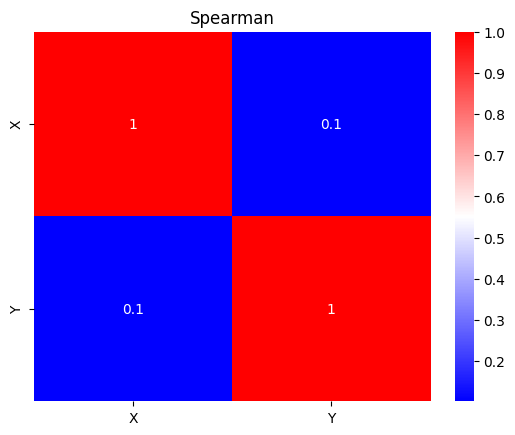

In [7]:
sns.heatmap(df[["X", "Y"]].corr(method="spearman"), annot=True, cmap="bwr")
plt.title("Spearman")
plt.show()

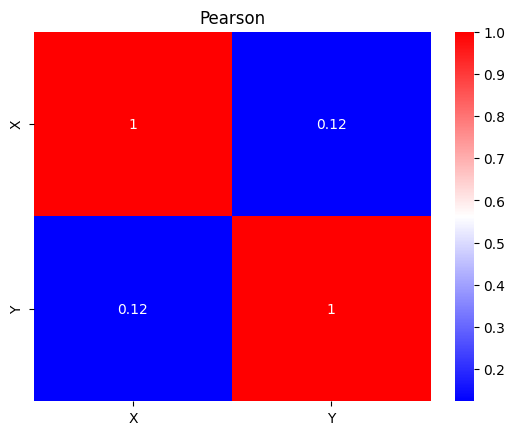

In [8]:
sns.heatmap(df[["X", "Y"]].corr(method="pearson"), annot=True, cmap="bwr")
plt.title("Pearson")
plt.show()

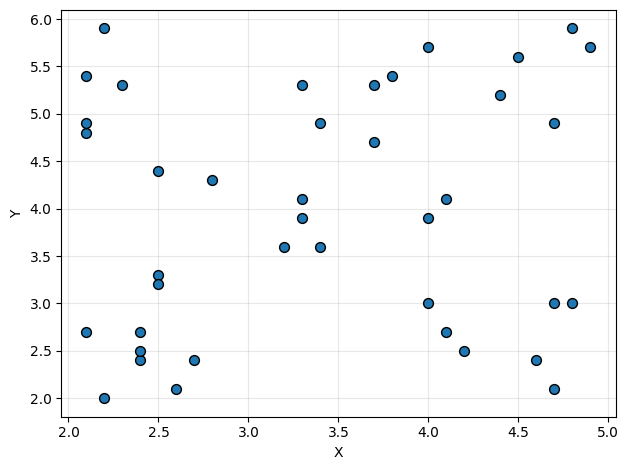

In [9]:
plt.scatter(x, y, s=50, ec="k", zorder=3)

plt.xlabel("X")
plt.ylabel("Y")

plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

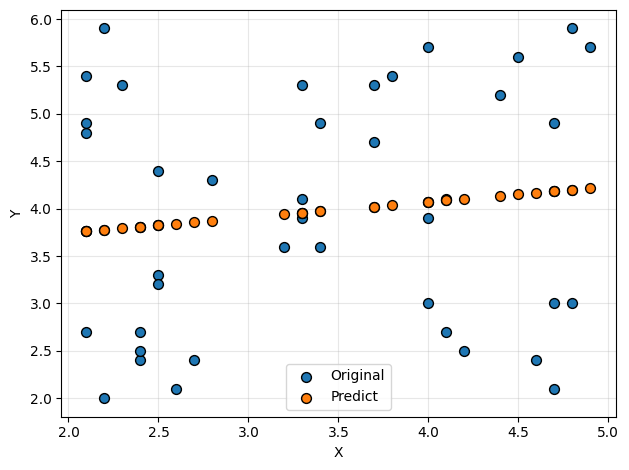

In [10]:
model = LinearRegression().fit(x.reshape(-1, 1), y.reshape(-1, 1))

plt.scatter(x, y, s=50, ec="k", zorder=3, label="Original")
plt.scatter(x, model.predict(x.reshape(-1, 1)), s=50, ec="k", zorder=3, label="Predict")

plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()